### Strategy and Insights

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("model_output.csv")
df.head()

,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,PurchaseFrequency,AvgDaysBetweenPurchases,CLV,Predicted_CLV
0,12346.0,326,1,77183.60,77183.600000,1.000000,0.0,77183.60,73570.6454
1,12347.0,2,7,4310.00,23.681319,0.019126,2.0,4310.00,4308.7422
2,12348.0,75,4,1797.24,57.975484,0.014134,9.4,1797.24,1797.4815
3,12349.0,19,1,1757.55,24.076027,1.000000,0.0,1757.55,1757.8304
4,12350.0,310,1,334.40,19.670588,1.000000,0.0,334.40,334.4341


#### Customer Segments

##### Segment based on Predicted CLV

In [3]:
df['CLV_Segment'] = pd.qcut(df['Predicted_CLV'],q=3, labels=['Low','Medium','High'])

##### Segment Analysis

In [4]:
segment_summary = df.groupby('CLV_Segment').agg({
    'Predicted_CLV': ['mean', 'count'],
    'Frequency': 'mean',
    'Monetary': 'mean'
})

segment_summary

C:\Users\peter\AppData\Local\Temp\ipykernel_5976\2524220201.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_summary = df.groupby('CLV_Segment').agg({


Predicted_CLV       Frequency     Monetary
                     mean count      mean         mean
CLV_Segment                                           
Low            220.601718  1446  1.325035   220.600906
Medium         712.591549  1446  2.573997   712.587284
High          5184.011479  1446  8.917012  5229.611190

##### Key Insights

- Customer value is highly skewed, with high CLV customers contributing disproportionately to revenue.
- Low CLV customers generate negative ROI, indicating inefficient marketing spend.
- Medium CLV customers present an opportunity for growth through targeted strategies.
- High CLV customers are the most valuable segment, driving the majority of profits.

#### ROI Simulation

In [5]:
# Assume marketing cost per user
cost_per_user = 100

# Assume return multiplier
df['Expected_Return'] = df['Predicted_CLV'] * 0.2

df['Profit']=df['Expected_Return'] - cost_per_user

df.groupby('CLV_Segment')['Profit'].mean()

C:\Users\peter\AppData\Local\Temp\ipykernel_5976\2345575901.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('CLV_Segment')['Profit'].mean()


CLV_Segment
Low       -55.879656
Medium     42.518310
High      936.802296
Name: Profit, dtype: float64

##### ROI Analysis

- Marketing investment in high CLV customers yields significantly higher returns (~$936 profit per user).
- Medium CLV customers generate moderate positive returns and represent a growth opportunity.
- Low CLV customers result in negative ROI (~₹55 loss per user), suggesting inefficient allocation of resources.

Recommendation:
Reallocate marketing budget from low-value customers to high and medium-value segments to maximize overall profitability.


#### Strategy Recommendations

##### for High CLV Customers
- Provide loyalty programs
- Early access to products
- Premium support
##### for Medium CLV Customers
- Upsell and cross-sell strategies
- Personalized recommendations
##### for Low CLV Customers
- Minimize marketing spend
- Use automated campaigns

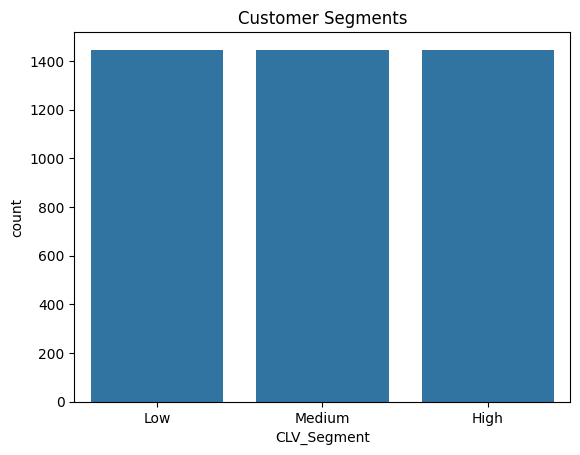

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='CLV_Segment', data=df)
plt.title("Customer Segments")
plt.show()

##### exporting dataset

In [7]:
df.to_csv("final_output.csv", index=False) 